# Checking yields on the Inclusive MC for  template grouping group3

In [1]:
%run load-rds-final-2012-23903000-rs.ipynb

Welcome to JupyROOT 6.28/00


Loaded rdf with 305828 enries


In [2]:
def mygroupby(d, groupbycols):
    g = d.groupby(groupbycols).size().reset_index(name='count').sort_values([ 'count'], ascending=False).reset_index(drop=True)
    g["Percentage"] = g.apply(lambda row: 100 * row["count"]/d.shape[0], axis=1)
    g["cumulative %"] = g["Percentage"].cumsum(axis = 0)
    return g

In [3]:
def categ_groupby(df, groupbycol, threshold):
    """ Group the dataframe df by column groupbycol, grouping together entries rows with count < threshold """
    g = pd.DataFrame(df.groupby(groupbycol).count()["category"]).rename(columns={"category":"count"})
    g["Category"] = g.apply(lambda row: row.name if row["count"] > threshold else "others", axis=1)
    g2 = g.groupby("Category").sum()
    g2 = g2.sort_values([ 'count'], ascending=False)
    total = g2.sum()["count"]
    g2["Percentage"] = g2.apply(lambda row: 100 * row["count"]/total, axis=1)
    g2["cumulative %"] = g2["Percentage"].cumsum(axis = 0)
    return g, g2

In [4]:
import categories4 as f
rdf_initial = rdf
rdf = f.add_categories_and_filter(rdf_initial,  apply_BDT_Iso_cut=True, apply_PIDK_cut=True)

In [5]:
base_columns = [ "eventIndex", "category", "simplified", "B_M", "B_Y_SEP", "Xc_signal_Ypis_displaced_fromBs_fromTau", "fromY_from_B_vertex", "BDT_Iso", "q2_2", "tauY_2"]
load_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
#     "log(abs(PBsn))",
#     "log(abs(PBv/B_P))",
#     "log(abs(PBvn/B_P))",
#     "log(abs((PBsn-PBvn)/PBvn))",
#     "log(sqrt(abs(mDs2vn)))",
    "mN2v",
#    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
    'PBsn',
    'PBv', 'PBvn', 'B_P', 'mDs2vn', 'Y_PE'
]
train_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
    "log(abs(PBsn))",
    "log(abs(PBv/B_P))",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "mN2v",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]

columns = base_columns +  load_columns
df = pd.DataFrame(rdf.Cache(columns).AsNumpy())


In [6]:
df['simplified_key'] = df.apply(lambda row: f.pretty_categories_map[row["simplified"]], axis=1)
df['key'] = df.apply(lambda row: f.categories_map[row["category"]], axis=1)
df['signal'] = (df['simplified_key'] == 'Signal')
dfbm = df.query("B_M < 5000")

In [7]:
df.query("B_M < 5000").query("signal == True").query("q2_2 > 0")

,BDT_Iso,B_BPVVDR,B_M,B_P,B_Y_SEP,B_correctedMass,B_pT_Bdir,PBsn,PBv,PBvn,...,max_m2pi,min_m2pi,missing_mass_2,missing_pY_mass,q2_2,simplified,tauY_2,simplified_key,key,signal
18,0.300701,1.251786,3555.436260,73440.504631,-5.396421,4648.655407,964.673579,95030.086006,119258.329865,102598.838899,...,717.463194,326.297603,634.665738,-309.581326,7.492151,1007,0.000324,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
27,0.304464,2.207561,4295.377515,161397.486742,-13.755033,4867.665362,538.646115,218321.801510,227549.612874,218321.949795,...,1136.189727,631.568058,341.499885,317.509062,4.852885,1007,0.000512,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
191,0.399764,3.409034,4101.212991,144294.265574,-29.192873,5547.156730,1257.491041,123290.341564,132639.509066,130663.716106,...,711.771211,547.652312,-1185.865988,536.725748,7.190575,1007,0.000946,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
192,0.060515,1.316995,4603.941355,152274.692578,-17.808110,5027.680017,405.882071,148826.309470,151727.047076,148868.065327,...,873.148779,786.979971,-356.337971,396.317398,5.524680,1007,0.000726,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
274,0.316373,1.963349,4468.346674,191079.648151,-6.288015,5286.581659,754.913492,161847.575966,179169.819382,161867.100541,...,721.087590,655.613555,-754.646648,517.683761,6.000162,1007,0.000149,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242268,0.235340,1.554001,3972.670890,207990.577214,-7.814765,5305.832564,1165.674289,292365.048373,351147.073467,316351.741998,...,932.845543,836.936942,-971.323028,486.019541,3.913299,1007,0.000234,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
242374,0.430140,6.910549,3387.932555,77325.281992,-23.642952,3737.534285,333.251195,81476.991060,88985.847274,81830.132992,...,595.212368,570.175348,852.768024,838.358234,8.128510,1007,0.000633,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
242395,0.198366,2.908379,3819.010212,90789.831007,-7.146156,4266.577350,424.092075,107943.957038,116331.299456,107979.802988,...,891.375999,764.576723,758.678435,529.004453,6.473756,1007,0.000470,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True
242476,0.229566,1.213361,4300.833408,145979.948903,-8.153945,5283.667754,891.424042,127477.921173,131290.652600,127653.882759,...,759.718200,435.177340,-815.592170,463.230325,7.859131,1007,0.000334,Signal,Xc_signal_Ypis_displaced_fromBs_fromTau,True


In [8]:
dfbm.query("BDT_Iso <  0.03458")

,BDT_Iso,B_BPVVDR,B_M,B_P,B_Y_SEP,B_correctedMass,B_pT_Bdir,PBsn,PBv,PBvn,...,max_m2pi,min_m2pi,missing_mass_2,missing_pY_mass,q2_2,simplified,tauY_2,simplified_key,key,signal


THIS INCLUDES THE CUT q2_2 > 0 BY DEFAULT

In [9]:
import joblib
bdtdblcharm = joblib.load("../../train_bdt/bdtdblcharm_150_3_0.04.pkl")
def add_cols_for_bdt(tmpdf):
    df = tmpdf.copy()
    df["log(abs(PBsn))"] = np.log(np.abs(df["PBsn"]))
    df["log(abs(PBv/B_P))"] = np.log(np.abs(df["PBv"] / df["B_P"]))
    df["log(abs(PBvn/B_P))"] = np.log(np.abs(df["PBvn"] / df["B_P"]))
    df["log(abs((PBsn-PBvn)/PBvn))"] = np.log(np.abs((df["PBsn"] - df["PBvn"]) / df["PBvn"]))
    df["log(sqrt(abs(mDs2vn)))"] = np.log(np.sqrt(np.abs(df["mDs2vn"])))
    df["log(Y_PE)"] = np.log(df["Y_PE"]) 
    df["diff_m2pi"] = df["max_m2pi"] - df["min_m2pi"]
    return df
dfbm2 = add_cols_for_bdt(dfbm)

In [10]:
dfbm2['bdt_dc'] = bdtdblcharm.predict_proba(dfbm2[train_columns])[:,1]

In [11]:
#dfbm2.to_hdf('data_with_bdt_dc.h5', key='df', mode='w')

In [12]:
dfbm2.query("signal == True")['category'].unique()

array([24, 10, 11], dtype=int32)

In [13]:
f.categories_map

{0: 'Xc_background',
 1: 'Xc_signal_Ypis_diffAncestorYXc',
 2: 'Xc_signal_Ypis_B_vertex_fromBs',
 3: 'Xc_signal_Ypis_B_vertex_fromOtherB',
 4: 'Xc_signal_Ypis_B_vertex_fromHc',
 5: 'Xc_signal_Ypis_B_vertex_fromNone',
 6: 'Xc_signal_Ypis_nomatch_Prompt',
 7: 'Xc_signal_Ypis_nomatch_doubleCharm',
 8: 'Xc_signal_Ypis_nomatch_charmStrange',
 9: 'Xc_signal_Ypis_nomatch_Other',
 10: 'Xc_signal_Ypis_diffVertex_signal',
 11: 'Xc_signal_Ypis_diffVertex_tauFromB',
 12: 'Xc_signal_Ypis_diffVertex_normlike',
 13: 'Xc_signal_Ypis_diffVertex_doubleCharm',
 14: 'Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB',
 15: 'Xc_signal_Ypis_diffVertex_doubleCharm_TwoFromB',
 16: 'Xc_signal_Ypis_diffVertex_CharmStrange',
 17: 'Xc_signal_Ypis_diffVertex_SomeFromPV',
 18: 'Xc_signal_Ypis_displaced_fromBs_fromDs',
 19: 'Xc_signal_Ypis_displaced_fromB0_fromDp',
 20: 'Xc_signal_Ypis_displaced_fromBp_fromD0',
 21: 'Xc_signal_Ypis_displaced_fromLambdab_fromLambdac',
 22: 'Xc_signal_Ypis_displaced_fromBs_fromDp',
 23: 

In [14]:
dfbm2

,BDT_Iso,B_BPVVDR,B_M,B_P,B_Y_SEP,B_correctedMass,B_pT_Bdir,PBsn,PBv,PBvn,...,key,signal,log(abs(PBsn)),log(abs(PBv/B_P)),log(abs(PBvn/B_P)),log(abs((PBsn-PBvn)/PBvn)),log(sqrt(abs(mDs2vn))),log(Y_PE),diff_m2pi,bdt_dc
0,0.142126,5.122865,3549.868167,168977.117807,-42.580564,4429.095708,791.959042,213931.912377,227255.066624,224798.696179,...,Xc_background,False,12.273413,0.296310,0.285442,-3.029495,7.911052,10.883605,414.693391,0.480915
1,0.084323,1.668125,3319.233948,61299.597437,-25.553933,3650.446180,316.186461,68422.978613,75375.247132,68627.893311,...,Xc_background,False,11.133464,0.206706,0.112926,-5.813861,7.786525,9.734375,197.234971,0.047678
2,0.368573,1.993594,3952.608126,156837.935763,-10.530797,4331.339197,362.173002,193830.018453,206759.162365,194002.880756,...,Xc_signal_Ypis_displaced_fromB0_fromDp,False,12.174737,0.276342,0.212660,-7.023133,7.734093,11.047794,35.228538,0.550376
3,0.152137,0.780185,3590.944305,86795.626730,-5.040866,4689.721792,970.058554,63525.280784,74187.153322,64659.427607,...,Xc_background,False,11.059193,-0.156965,-0.294422,-4.043253,7.936118,10.755483,143.757553,0.744786
4,0.382045,1.299142,3747.756129,148853.385470,-5.497857,4000.589420,244.843884,152223.181078,163115.939253,152258.133512,...,Xc_signal_Ypis_displaced_fromBs_fromDs,False,11.933103,0.091499,0.022615,-8.379345,7.086510,9.932745,56.547468,0.057617
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242735,0.321024,4.012284,4027.889398,202833.051607,-20.939083,5027.599310,900.316559,278687.778202,301173.947829,286704.281254,...,Xc_signal_Ypis_displaced_fromBs_fromDs,False,12.537847,0.395305,0.346068,-3.576949,7.392935,11.387447,558.693289,0.197994
242736,0.132013,0.912369,4565.097589,171913.729033,-12.364674,5011.791461,426.787276,169474.374381,172384.198847,169695.757786,...,Xc_signal_Ypis_displaced_fromBs_fromDs,False,12.040457,0.002733,-0.012986,-6.641866,7.637914,10.947215,93.671025,0.435207
242737,0.340379,1.283536,4689.555203,142928.520106,-29.903899,6174.122483,1306.085235,123794.055575,126366.400090,123879.637927,...,Xc_signal_Ypis_displaced_fromBs_fromDs,False,11.726375,-0.123159,-0.143034,-7.277587,7.654822,10.930162,275.300333,0.302139
242738,0.266166,1.156650,3400.800053,108148.088194,-5.197422,4531.720777,989.806372,145142.143730,176817.601762,145184.537346,...,Xc_signal_Ypis_nomatch_doubleCharm,False,11.885469,0.491617,0.294504,-8.138763,7.694428,10.076992,399.626947,0.345274


# Loading the template

In [15]:
import yaml
from yaml import SafeLoader
# Loading the template configuration
with open("../config/templates.yaml") as yf:
    templates_config = yaml.load(yf, Loader=SafeLoader)

In [16]:
group3 = templates_config['templates']['group3']

In [17]:
group3_map = {}
group3_others = None
for i, c in enumerate(group3):
    if type(c) == int:
        group3_map[c] = i
    elif c == 'others':
        group3_others = i
    else:
        for cc in c:
            if cc == 'others':
                group3_others = i
            else:
                group3_map[cc] = i

def get_group3_categories(bkgcat):
    return group3[group3_map.get(bkgcat, group3_others)]

def _g1cat2name(cat):
    if type(cat) == int:
        tmp = f.categories_map[cat]
        if tmp == "Xc_signal_Ypis_displaced_fromBs_fromTau":
            return "Signal"
        elif tmp in ['Xc_signal_Ypis_diffVertex_signal', 'Xc_signal_Ypis_diffVertex_tauFromB']:
            return None
        return tmp.replace("Xc_signal_Ypis_", "")
    elif cat == 'others':
        return 'others'
    elif type(cat) == list:
        #print(cat)
        catnames = [ _g1cat2name(c) for c in cat]
        #print(f"===> {catnames}")
        return ", ".join([cc for cc in catnames if cc is not None])
        #return ", ".join([cc for cc in catnames in cc is not None])
 

def _get_group3_name(c):
    #print(f"==>categ {c}")
    return _g1cat2name(group3[int(c)])
        
def _template_name(g):
    prefix = "TemplateCat"
    if type(g) == list:
        return prefix + "_".join([str(gg) for gg in g])
    else:
        return prefix + str(g)
    
for g in group3:
    print(f"{g} -> {[f.categories_map[gg] for gg in g] if type(g) == list else 'others' if g == 'others' else f.categories_map[g] }")

    
cat_mapper = { _g1cat2name(g):_template_name(g)  for g in group3}
cat_mapper['Signal'] = 'Signal'

[24, 10, 11] -> ['Xc_signal_Ypis_displaced_fromBs_fromTau', 'Xc_signal_Ypis_diffVertex_signal', 'Xc_signal_Ypis_diffVertex_tauFromB']
20 -> Xc_signal_Ypis_displaced_fromBp_fromD0
[18, 29] -> ['Xc_signal_Ypis_displaced_fromBs_fromDs', 'Xc_signal_Ypis_displaced_fromBs_fromDs_fromTau']
21 -> Xc_signal_Ypis_displaced_fromLambdab_fromLambdac
[25, 13, 19, 7] -> ['Xc_signal_Ypis_displaced_fromB0_fromD0', 'Xc_signal_Ypis_diffVertex_doubleCharm', 'Xc_signal_Ypis_displaced_fromB0_fromDp', 'Xc_signal_Ypis_nomatch_doubleCharm']
[16, 14] -> ['Xc_signal_Ypis_diffVertex_CharmStrange', 'Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB']
others -> others
[23, 22, 26, 27] -> ['Xc_signal_Ypis_displaced_fromBp_fromDp', 'Xc_signal_Ypis_displaced_fromBs_fromDp', 'Xc_signal_Ypis_displaced_fromB0_fromDs', 'Xc_signal_Ypis_displaced_fromBs_fromD0']
0 -> Xc_background
15 -> Xc_signal_Ypis_diffVertex_doubleCharm_TwoFromB


In [18]:
dfbm2['group3_category'] = dfbm2.apply(lambda row: group3_map.get(row['category'], group3_others), axis=1)
dfbm2['group3_name'] = dfbm2.apply(lambda row: _get_group3_name(row['group3_category']), axis=1)
#dfbm2



In [19]:
pd.set_option('display.max_colwidth', None)
stat_g3 = mygroupby(dfbm2, 'group3_name')

# Correlations between the variables for each group

In [20]:
dfbm2[['q2_2', 'tauY_2', "bdt_dc", 'group3_name']].corr()

/tmp/ipykernel_194857/1520007724.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  dfbm2[['q2_2', 'tauY_2', "bdt_dc", 'group3_name']].corr()


,q2_2,tauY_2,bdt_dc
q2_2,1.000000,0.000772,0.188696
tauY_2,0.000772,1.000000,-0.066909
bdt_dc,0.188696,-0.066909,1.000000


## Evaluating datasets after cuts

In [21]:
df_cut1 = dfbm2.query("bdt_dc >0.75")

In [22]:
stat_g1 = mygroupby(df_cut1, 'group3_name')
stat_g1.set_index('group3_name', inplace=True)
signal_count = int(232 * stat_g1.loc['Signal', 'count'] / 3562)
print(f"Ratio of candidates in current sample vs 2invfb {3562/232}")
signal_percentage = stat_g1.loc['Signal', 'Percentage'] 
print(f"{signal_percentage} ==> {signal_count}")
ratio = signal_count / signal_percentage
print(ratio)
stat_g1['yield_2invfb'] = stat_g1.apply(lambda row: int(row['Percentage'] * ratio), axis=1)
stat_g1['name'] = stat_g1.index
stat_g1['empty'] = ""
stat_g1

Ratio of candidates in current sample vs 2invfb 15.35344827586207
10.7387089501766 ==> 93
8.660258922323303


,count,Percentage,cumulative %,yield_2invfb,name,empty
group3_name,,,,,,
"displaced_fromB0_fromD0, diffVertex_doubleCharm, displaced_fromB0_fromDp, nomatch_doubleCharm",4044,30.390020,30.390020,263,"displaced_fromB0_fromD0, diffVertex_doubleCharm, displaced_fromB0_fromDp, nomatch_doubleCharm",
"displaced_fromBp_fromDp, displaced_fromBs_fromDp, displaced_fromB0_fromDs, displaced_fromBs_fromD0",2665,20.027053,50.417074,173,"displaced_fromBp_fromDp, displaced_fromBs_fromDp, displaced_fromB0_fromDs, displaced_fromBs_fromD0",
Signal,1429,10.738709,61.155783,93,Signal,
"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",1388,10.430600,71.586383,90,"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",
Xc_background,1337,10.047344,81.633727,87,Xc_background,
"displaced_fromBs_fromDs, displaced_fromBs_fromDs_fromTau",885,6.650635,88.284362,57,"displaced_fromBs_fromDs, displaced_fromBs_fromDs_fromTau",
displaced_fromBp_fromD0,731,5.493349,93.777711,47,displaced_fromBp_fromD0,
others,414,3.111145,96.888855,26,others,
displaced_fromLambdab_fromLambdac,278,2.089126,98.977982,18,displaced_fromLambdab_fromLambdac,


In [23]:
print(stat_g1[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))

\begin{tabular}{llrr}
\toprule
empty &                                                                                               name &  Percentage &  yield\_2invfb \\
      &      displaced\_fromB0\_fromD0, diffVertex\_doubleCharm, displaced\_fromB0\_fromDp, nomatch\_doubleCharm &       30.39 &           263 \\
\midrule
      & displaced\_fromBp\_fromDp, displaced\_fromBs\_fromDp, displaced\_fromB0\_fromDs, displaced\_fromBs\_fromD0 &       20.03 &           173 \\
      &                                                                                             Signal &       10.74 &            93 \\
      &                                           diffVertex\_CharmStrange, diffVertex\_doubleCharm\_OneFromB &       10.43 &            90 \\
      &                                                                                      Xc\_background &       10.05 &            87 \\
      &                                           displaced\_fromBs\_fromDs, displaced\_fromBs\_fromD

/tmp/ipykernel_194857/1193698796.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(stat_g1[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))


In [24]:
df_cut2 = dfbm2.query("bdt_dc >0.35")
stat_g2 = mygroupby(df_cut2, 'group3_name')
stat_g2.set_index('group3_name', inplace=True)
signal_count = int(232 * stat_g2.loc['Signal', 'count'] / 3562)
signal_percentage = stat_g2.loc['Signal', 'Percentage'] 
print(f"{signal_percentage} ==> {signal_count}")
ratio = signal_count / signal_percentage
stat_g2['yield_2invfb'] = stat_g2.apply(lambda row: int(row['Percentage'] * ratio), axis=1)
stat_g2['name'] = stat_g2.index
stat_g2['empty'] = ""
print(stat_g2[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))
stat_g2

3.3072859344045784 ==> 195
\begin{tabular}{llrr}
\toprule
empty &                                                                                               name &  Percentage &  yield\_2invfb \\
      &      displaced\_fromB0\_fromD0, diffVertex\_doubleCharm, displaced\_fromB0\_fromDp, nomatch\_doubleCharm &       33.67 &          1985 \\
\midrule
      &                                           displaced\_fromBs\_fromDs, displaced\_fromBs\_fromDs\_fromTau &       13.78 &           812 \\
      &                                           diffVertex\_CharmStrange, diffVertex\_doubleCharm\_OneFromB &       13.20 &           778 \\
      & displaced\_fromBp\_fromDp, displaced\_fromBs\_fromDp, displaced\_fromB0\_fromDs, displaced\_fromBs\_fromD0 &       12.71 &           749 \\
      &                                                                                      Xc\_background &        9.19 &           541 \\
      &                                                              

/tmp/ipykernel_194857/3553877674.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(stat_g2[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))


,count,Percentage,cumulative %,yield_2invfb,name,empty
group3_name,,,,,,
"displaced_fromB0_fromD0, diffVertex_doubleCharm, displaced_fromB0_fromDp, nomatch_doubleCharm",30590,33.667180,33.667180,1985,"displaced_fromB0_fromD0, diffVertex_doubleCharm, displaced_fromB0_fromDp, nomatch_doubleCharm",
"displaced_fromBs_fromDs, displaced_fromBs_fromDs_fromTau",12524,13.783843,47.451024,812,"displaced_fromBs_fromDs, displaced_fromBs_fromDs_fromTau",
"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",11996,13.202729,60.653753,778,"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",
"displaced_fromBp_fromDp, displaced_fromBs_fromDp, displaced_fromB0_fromDs, displaced_fromBs_fromD0",11547,12.708563,73.362316,749,"displaced_fromBp_fromDp, displaced_fromBs_fromDp, displaced_fromB0_fromDs, displaced_fromBs_fromD0",
Xc_background,8352,9.192164,82.554479,541,Xc_background,
displaced_fromBp_fromD0,7508,8.263262,90.817742,487,displaced_fromBp_fromD0,
Signal,3005,3.307286,94.125028,195,Signal,
displaced_fromLambdab_fromLambdac,2424,2.667841,96.792868,157,displaced_fromLambdab_fromLambdac,
others,2223,2.446621,99.239489,144,others,


In [25]:
df_cut3 = dfbm2.query("bdt_dc >0.50")
stat_g3 = mygroupby(df_cut3, 'group3_name')
stat_g3.set_index('group3_name', inplace=True)
signal_count = int(232 * stat_g3.loc['Signal', 'count'] / 3562)
signal_percentage = stat_g3.loc['Signal', 'Percentage'] 
print(f"{signal_percentage} ==> {signal_count}")
ratio = signal_count / signal_percentage
stat_g3['yield_2invfb'] = stat_g3.apply(lambda row: int(row['Percentage'] * ratio), axis=1)
stat_g3['name'] = stat_g3.index
stat_g3['empty'] = ""
print(stat_g3[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))

4.811940741840864 ==> 168
\begin{tabular}{llrr}
\toprule
empty &                                                                                               name &  Percentage &  yield\_2invfb \\
      &      displaced\_fromB0\_fromD0, diffVertex\_doubleCharm, displaced\_fromB0\_fromDp, nomatch\_doubleCharm &       33.48 &          1169 \\
\midrule
      & displaced\_fromBp\_fromDp, displaced\_fromBs\_fromDp, displaced\_fromB0\_fromDs, displaced\_fromBs\_fromD0 &       14.68 &           512 \\
      &                                           diffVertex\_CharmStrange, diffVertex\_doubleCharm\_OneFromB &       12.79 &           446 \\
      &                                           displaced\_fromBs\_fromDs, displaced\_fromBs\_fromDs\_fromTau &       11.14 &           389 \\
      &                                                                                      Xc\_background &        9.56 &           333 \\
      &                                                               

/tmp/ipykernel_194857/471092861.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(stat_g3[['empty', 'name', 'Percentage', 'yield_2invfb']].to_latex(float_format="%.2f", index=False))


# Checking the correlations within the group

In [26]:
group3

[[24, 10, 11],
 20,
 [18, 29],
 21,
 [25, 13, 19, 7],
 [16, 14],
 'others',
 [23, 22, 26, 27],
 0,
 15]

In [27]:
all_others = [ c for c in dfbm2['category'].unique() if c not in group3_map ]
all_others
to_check = [] 
for i, g in enumerate(group3):
    if type(g) == list:
        print(g)

[24, 10, 11]
[18, 29]
[25, 13, 19, 7]
[16, 14]
[23, 22, 26, 27]


In [28]:
#dfbm2.query("category == 24")[['q2_2', 'tauY_2', "bdt_dc"]].corr()

# Checking category [18, 29]

Xc_signal_Ypis_displaced_fromBs_fromDs
Xc_signal_Ypis_displaced_fromBs_fromDs_fromTau


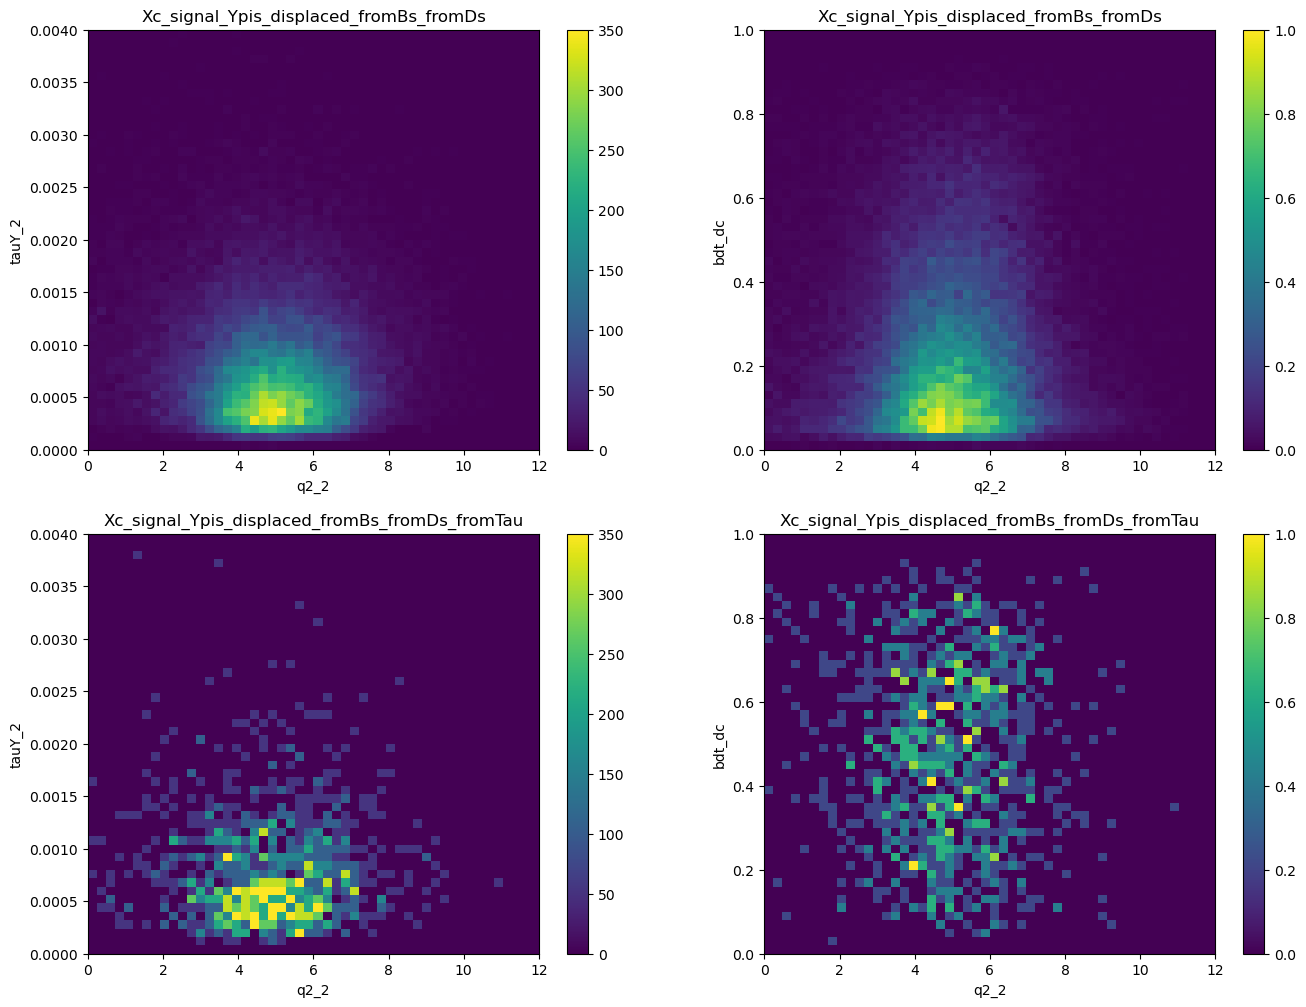

In [29]:
category1 = 18
category2 = 29

print(f.categories_map[category1])
print(f.categories_map[category2])

ranges = {
    'tauY_2': [ 0, 0.004],
    'bdt_dc': [ 0, 1],
    'q2_2': [ 0, 12.0],
}

def myplot(df, category, var1, var2, ax, vmax, bins=50):
    h = ax.hist2d(df[var1], df[var2], bins=bins, density=True, range=[ranges[var1], ranges[var2]], vmax=vmax);
    ax.set_xlabel(var1)
    ax.set_ylabel(var2)
    title = "Others"
    if category < 999:
        title = f"{f.categories_map[category]}"
    ax.set_title(title)
    fig.colorbar(h[3], ax=ax)

dftmp1 = dfbm2.query(f"category == {category1}")
dftmp2 = dfbm2.query(f"category == {category2}")

vmax_tau = 350
vmax_bdt = 1
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
myplot(dftmp1, category1, 'q2_2', 'tauY_2', axs[0][0], vmax_tau)
myplot(dftmp2, category2, 'q2_2', 'tauY_2', axs[1][0], vmax_tau)
myplot(dftmp1, category1, 'q2_2', 'bdt_dc', axs[0][1], vmax_bdt)
myplot(dftmp2, category2, 'q2_2', 'bdt_dc', axs[1][1], vmax_bdt)
fig.savefig(f"g3_2D_corr_{category1}_{category2}.png")

# Checking category [16, 14]

Xc_signal_Ypis_diffVertex_CharmStrange
Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB


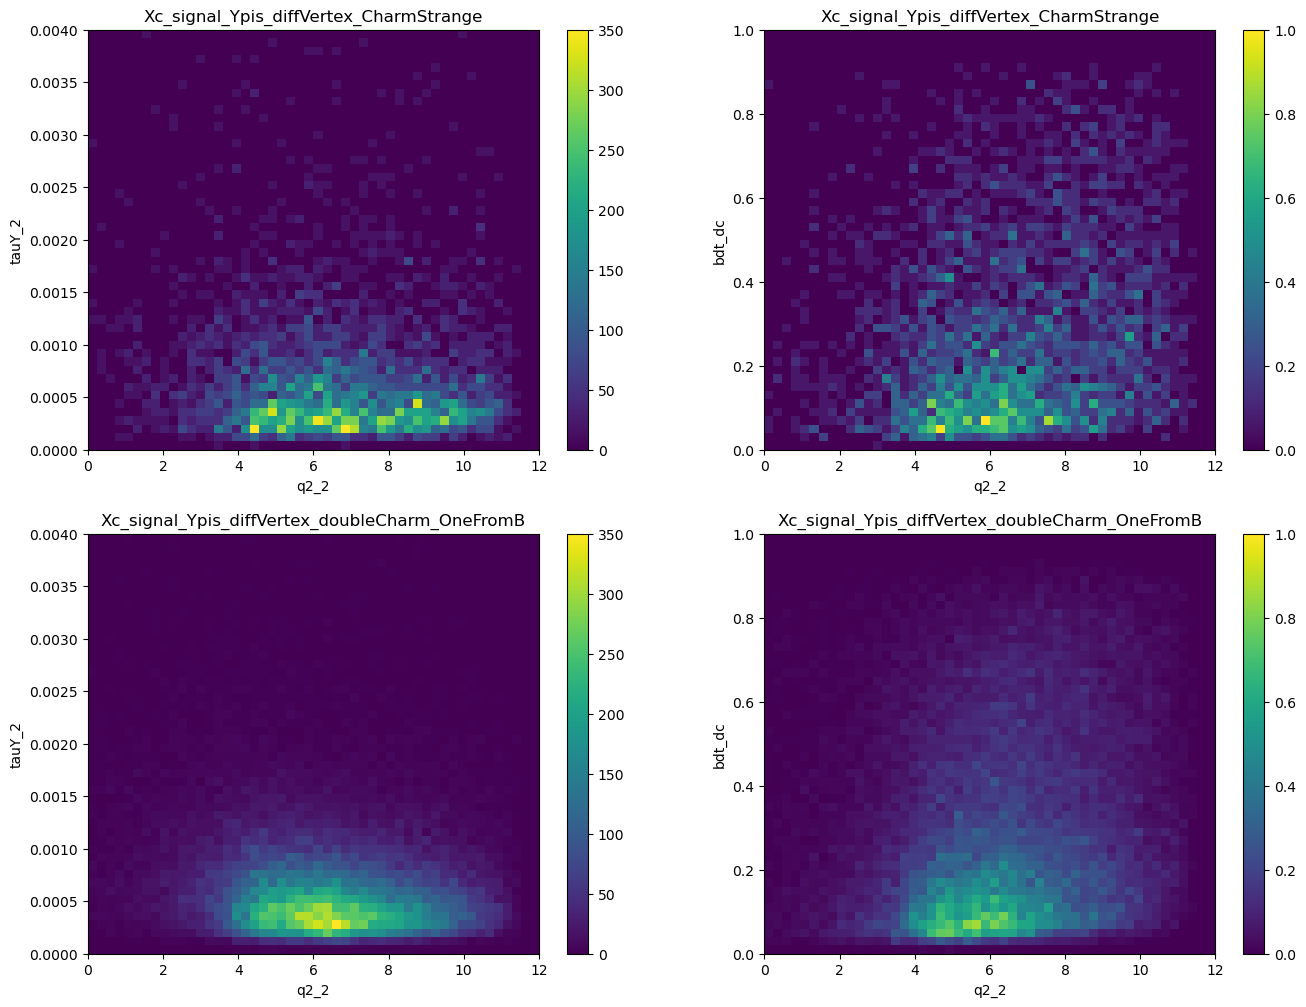

In [30]:
category1 = 16
category2 = 14

print(f.categories_map[category1])
print(f.categories_map[category2])

dftmp1 = dfbm2.query(f"category == {category1}")
dftmp2 = dfbm2.query(f"category == {category2}")
vmax_tau = 350
vmax_bdt = 1
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
myplot(dftmp1, category1, 'q2_2', 'tauY_2', axs[0][0], vmax_tau)
myplot(dftmp2, category2, 'q2_2', 'tauY_2', axs[1][0], vmax_tau)
myplot(dftmp1, category1, 'q2_2', 'bdt_dc', axs[0][1], vmax_bdt)
myplot(dftmp2, category2, 'q2_2', 'bdt_dc', axs[1][1], vmax_bdt)
fig.savefig(f"g3_2D_corr_{category1}_{category2}.png")

# Checking category [25, 7, 19, 13]

Xc_signal_Ypis_displaced_fromB0_fromD0
Xc_signal_Ypis_nomatch_doubleCharm
Xc_signal_Ypis_displaced_fromB0_fromDp
Xc_signal_Ypis_diffVertex_doubleCharm


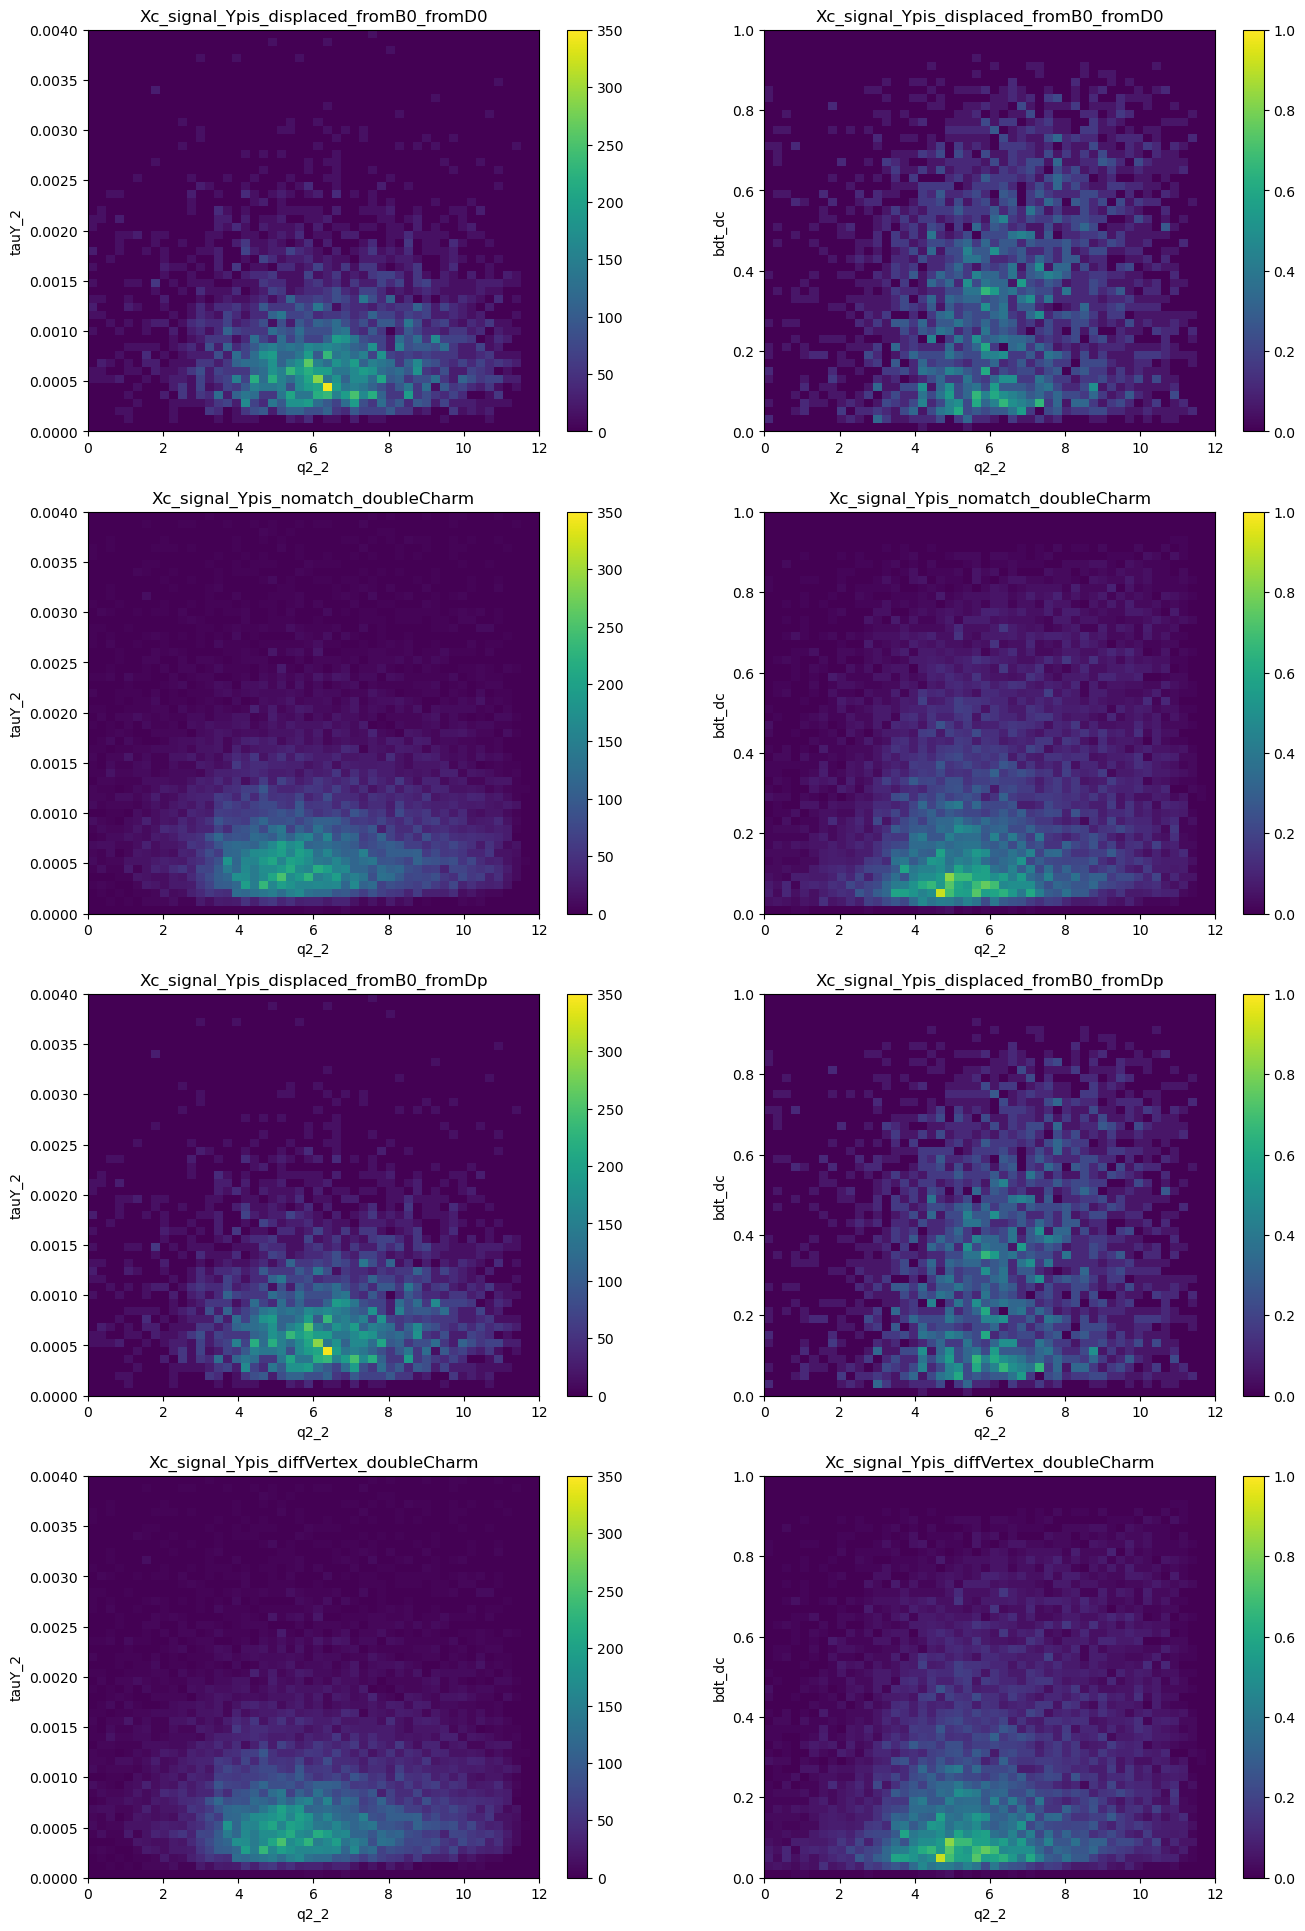

In [31]:
category1 = 25
category2 = 7
category3 = 19
category4 = 13

print(f.categories_map[category1])
print(f.categories_map[category2])
print(f.categories_map[category3])
print(f.categories_map[category4])

dftmp1 = dfbm2.query(f"category == {category1}")
dftmp2 = dfbm2.query(f"category == {category2}")
dftmp3 = dfbm2.query(f"category == {category3}")
dftmp4 = dfbm2.query(f"category == {category4}")
vmax_tau = 350
vmax_bdt = 1
fig, axs = plt.subplots(4, 2, figsize=(16, 24))
myplot(dftmp1, category1, 'q2_2', 'tauY_2', axs[0][0], vmax_tau)
myplot(dftmp2, category2, 'q2_2', 'tauY_2', axs[1][0], vmax_tau)
myplot(dftmp1, category1, 'q2_2', 'bdt_dc', axs[0][1], vmax_bdt)
myplot(dftmp2, category2, 'q2_2', 'bdt_dc', axs[1][1], vmax_bdt)
myplot(dftmp1, category3, 'q2_2', 'tauY_2', axs[2][0], vmax_tau)
myplot(dftmp2, category4, 'q2_2', 'tauY_2', axs[3][0], vmax_tau)
myplot(dftmp1, category3, 'q2_2', 'bdt_dc', axs[2][1], vmax_bdt)
myplot(dftmp2, category4, 'q2_2', 'bdt_dc', axs[3][1], vmax_bdt)
fig.savefig(f"g3_2D_corr_{category1}_{category2}_{category3}_{category4}.png")

# Checking category [22, 23, 26, 27]

Xc_signal_Ypis_displaced_fromBs_fromDp
Xc_signal_Ypis_displaced_fromBp_fromDp
Xc_signal_Ypis_displaced_fromB0_fromDs
Xc_signal_Ypis_displaced_fromBs_fromD0


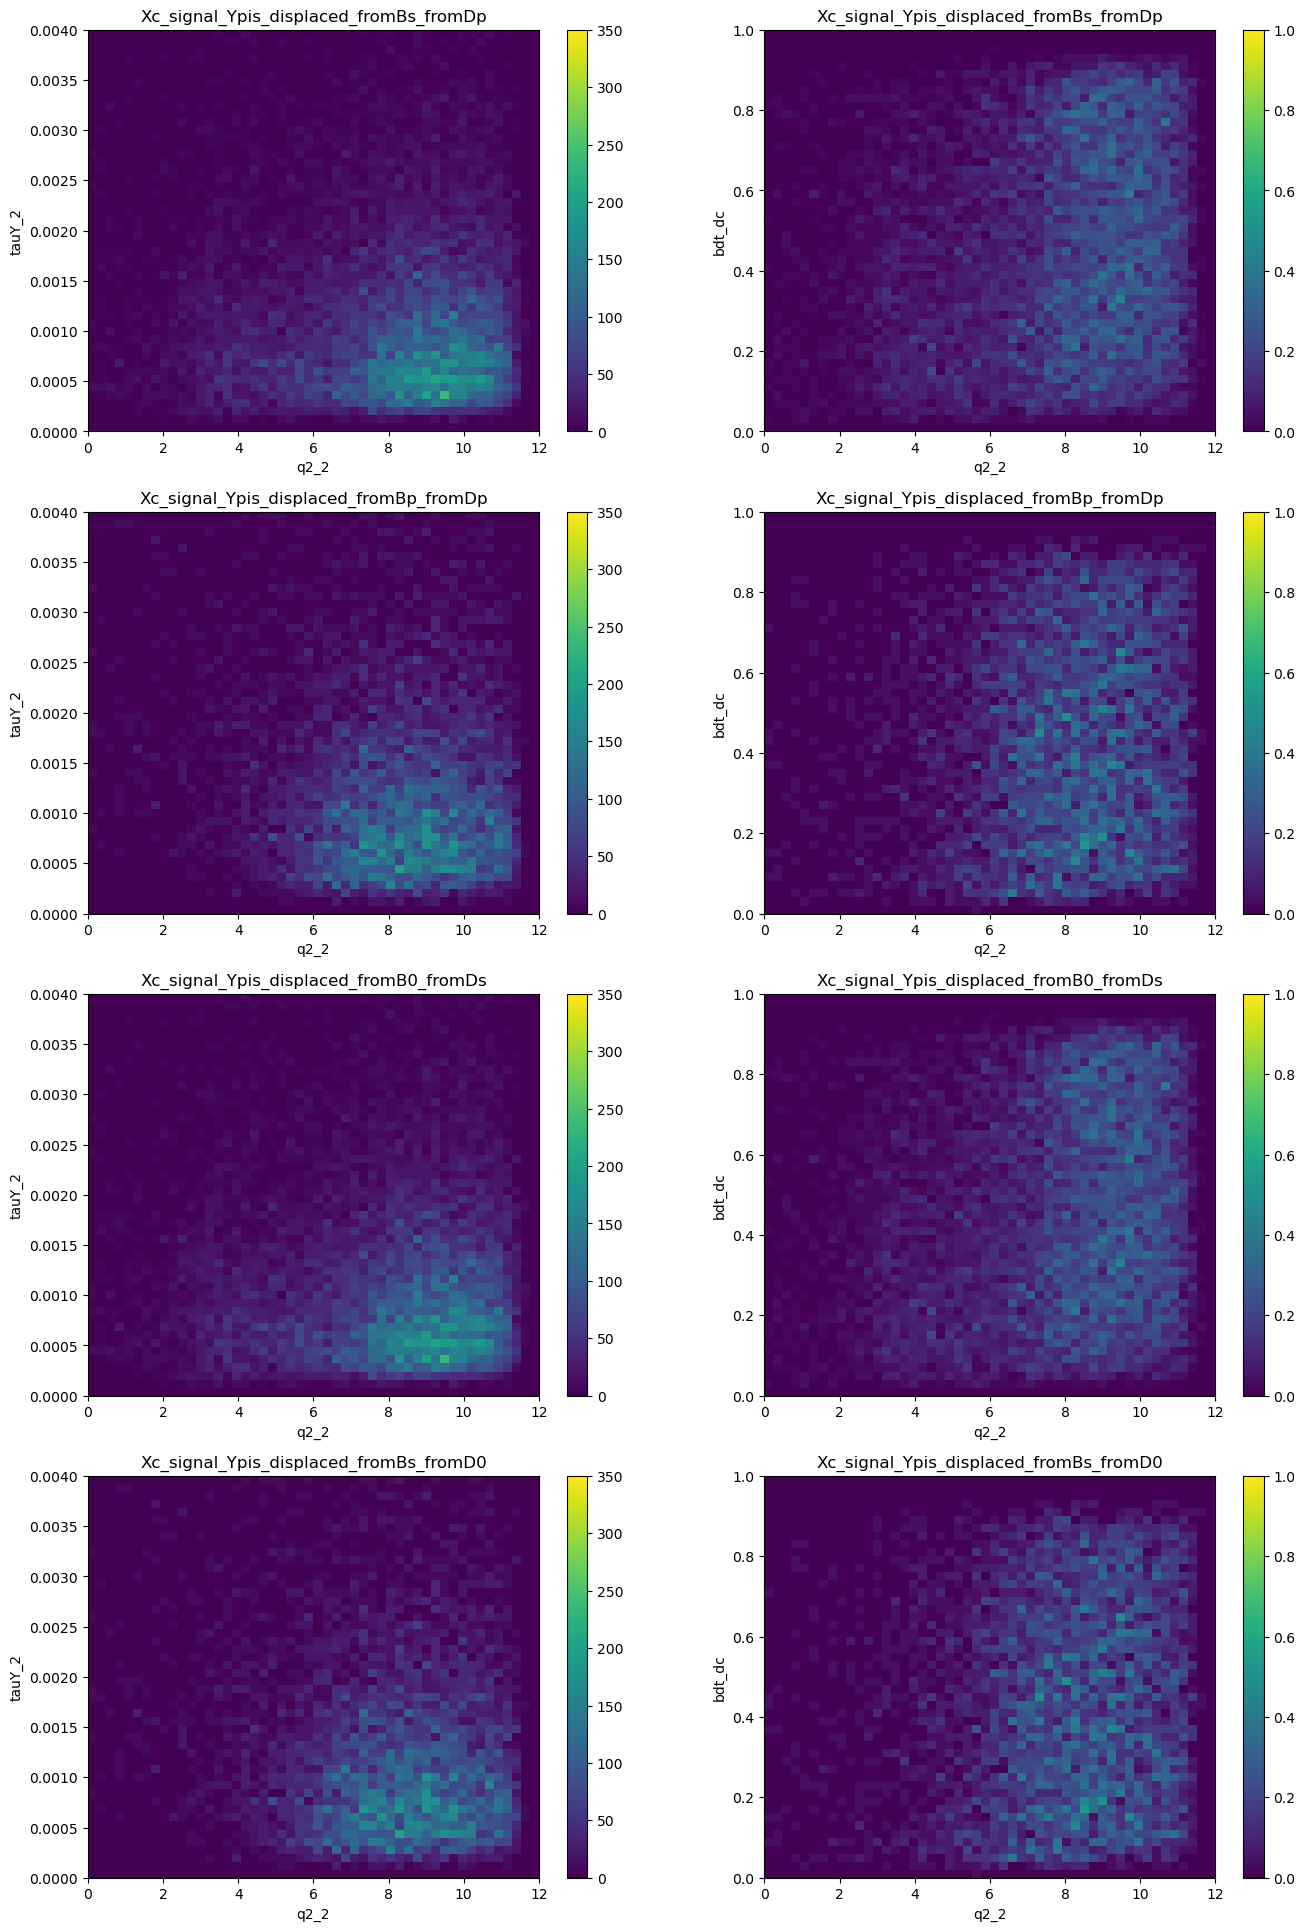

In [32]:
category1 = 22
category2 = 23
category3 = 26
category4 = 27

print(f.categories_map[category1])
print(f.categories_map[category2])
print(f.categories_map[category3])
print(f.categories_map[category4])

dftmp1 = dfbm2.query(f"category == {category1}")
dftmp2 = dfbm2.query(f"category == {category2}")
dftmp3 = dfbm2.query(f"category == {category3}")
dftmp4 = dfbm2.query(f"category == {category4}")
vmax_tau = 350
vmax_bdt = 1
fig, axs = plt.subplots(4, 2, figsize=(16, 24))
myplot(dftmp1, category1, 'q2_2', 'tauY_2', axs[0][0], vmax_tau)
myplot(dftmp2, category2, 'q2_2', 'tauY_2', axs[1][0], vmax_tau)
myplot(dftmp1, category1, 'q2_2', 'bdt_dc', axs[0][1], vmax_bdt)
myplot(dftmp2, category2, 'q2_2', 'bdt_dc', axs[1][1], vmax_bdt)
myplot(dftmp1, category3, 'q2_2', 'tauY_2', axs[2][0], vmax_tau)
myplot(dftmp2, category4, 'q2_2', 'tauY_2', axs[3][0], vmax_tau)
myplot(dftmp1, category3, 'q2_2', 'bdt_dc', axs[2][1], vmax_bdt)
myplot(dftmp2, category4, 'q2_2', 'bdt_dc', axs[3][1], vmax_bdt)
fig.savefig(f"g3_2D_corr_{category1}_{category2}_{category3}_{category4}.png")

In [33]:
# This is the list of categories handled by the group1 categorization - the OTHERS are esigned by "others"
group3_included = []
for c in group3:
    if c == 'others':
        continue
    elif type(c) == list:
        group3_included += [ cc for cc in c if cc != 'others' ]
    else:
        group3_included.append(c)
print(group3_included)

[24, 10, 11, 20, 18, 29, 21, 25, 13, 19, 7, 16, 14, 23, 22, 26, 27, 0, 15]


In [34]:
group3

[[24, 10, 11],
 20,
 [18, 29],
 21,
 [25, 13, 19, 7],
 [16, 14],
 'others',
 [23, 22, 26, 27],
 0,
 15]

In [35]:
# all_bkgcategs = set(f.categories_map.keys())
# others = all_bkgcategs - set(group3_included)

In [36]:
# dfothers = dfbm2.query(f"category in  {list(others)}")
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# myplot(dfothers, 999, 'q2_2', 'tauY_2', ax1)
# myplot(dfothers, 999, 'q2_2', 'bdt_dc', ax2)
# fig.savefig(f"2D_corr_others.png")

# Exporting the data for the fit

In [37]:
cutname = "cut1"
cutval = 0.75

def export_th3d(cutname, cutval):
    fileOutput = ROOT.TFile(f"DataMC_{cutname}.root","RECREATE")
    data = ROOT.TH3D("Dati","Dati",5,0,11,5,0,0.002,5,cutval,1.)
    dftmp = dfbm2.query(f"bdt_dc > {cutval}")[['q2_2', 'tauY_2', 'bdt_dc']]
    for index, row in dftmp.iterrows():
        data.Fill(row.q2_2, row.tauY_2, row.bdt_dc)
    fileOutput.cd()
    data.Write()
    fileOutput.Close()

export_th3d("cut1", 0.75)
export_th3d("cut2", 0.35)
export_th3d("cut3", 0.5)

In [38]:
!ls -l DataMC*

-rw-r--r-- 1 lben lben 4486 Okt  1 21:22 DataMC_cut1.root
-rw-r--r-- 1 lben lben 4656 Okt  1 21:22 DataMC_cut2.root
-rw-r--r-- 1 lben lben 4637 Okt  1 21:22 DataMC_cut3.root


In [39]:
!pwd

/home/lben/phys/rdshad/export_templates/notebooks


# Comparing the statistics on the fit

In [40]:

group3_mapping_names = {
    "TemplateCat25_13_19_7": "DoubleCharm1",
    "TemplateCat23_22_26_27": "DoubleCharm2",
    "TemplateCat24_10_11": "Signal",
    "TemplateCat16_14": "DoubleCharm3",
    "TemplateCat0": "BadDs",
    "TemplateCat18_29": "DoubleCharm4",
    "TemplateCat20": "DoubleCharm5",
    "TemplateCatothers": "Others",
    "TemplateCat21": "Lambdab",
    "TemplateCat15": "DoubleCharm6",
}

In [41]:
stat_g1

,count,Percentage,cumulative %,yield_2invfb,name,empty
group3_name,,,,,,
"displaced_fromB0_fromD0, diffVertex_doubleCharm, displaced_fromB0_fromDp, nomatch_doubleCharm",4044,30.390020,30.390020,263,"displaced_fromB0_fromD0, diffVertex_doubleCharm, displaced_fromB0_fromDp, nomatch_doubleCharm",
"displaced_fromBp_fromDp, displaced_fromBs_fromDp, displaced_fromB0_fromDs, displaced_fromBs_fromD0",2665,20.027053,50.417074,173,"displaced_fromBp_fromDp, displaced_fromBs_fromDp, displaced_fromB0_fromDs, displaced_fromBs_fromD0",
Signal,1429,10.738709,61.155783,93,Signal,
"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",1388,10.430600,71.586383,90,"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",
Xc_background,1337,10.047344,81.633727,87,Xc_background,
"displaced_fromBs_fromDs, displaced_fromBs_fromDs_fromTau",885,6.650635,88.284362,57,"displaced_fromBs_fromDs, displaced_fromBs_fromDs_fromTau",
displaced_fromBp_fromD0,731,5.493349,93.777711,47,displaced_fromBp_fromD0,
others,414,3.111145,96.888855,26,others,
displaced_fromLambdab_fromLambdac,278,2.089126,98.977982,18,displaced_fromLambdab_fromLambdac,


In [100]:
import re
from uncertainties import ufloat

fitres = """
RooRealVar::norm_TemplateCat0 = 2146.74 +/- 529.019  L(0 - 100000) 
RooRealVar::norm_TemplateCat15 = 393.943 +/- 206.443  L(0 - 100000) 
RooRealVar::norm_TemplateCat16_14 = 1303.98 +/- 328.994  L(0 - 100000) 
RooRealVar::norm_TemplateCat18_29 = 1067.47 +/- 235.28  L(0 - 100000) 
RooRealVar::norm_TemplateCat20 = 363.686 +/- 400.182  L(0 - 100000) 
RooRealVar::norm_TemplateCat21 = 99.27 +/- 135.001  L(0 - 100000) 
RooRealVar::norm_TemplateCat23_22_26_27 = 2113.53 +/- 322.253  L(0 - 100000) 
RooRealVar::norm_TemplateCat25_13_19_7 = 3207.39 +/- 504.775  L(0 - 100000) 
RooRealVar::norm_TemplateCatothers = 201.6 +/- 279.706  L(0 - 100000) 
RooRealVar::norm_Signal = 1259.93 +/- 151.605  L(0 - 100000) 
"""
results = {}
for l in fitres.splitlines():
    print(l)
    m = re.match("RooRealVar::norm_(TemplateCat.*|Signal) = ([\d\.]+) .*- ([\d\.]+)  L", l)
    if m:
        #print(f"{m.group(1)} {m.group(2)} {m.group(3)}")
        val = int(round(float(m.group(2)), -1))
        err = int(round(float(m.group(3)), -1))
        results[m.group(1)] = (val, err)
results


RooRealVar::norm_TemplateCat0 = 2146.74 +/- 529.019  L(0 - 100000) 
RooRealVar::norm_TemplateCat15 = 393.943 +/- 206.443  L(0 - 100000) 
RooRealVar::norm_TemplateCat16_14 = 1303.98 +/- 328.994  L(0 - 100000) 
RooRealVar::norm_TemplateCat18_29 = 1067.47 +/- 235.28  L(0 - 100000) 
RooRealVar::norm_TemplateCat20 = 363.686 +/- 400.182  L(0 - 100000) 
RooRealVar::norm_TemplateCat21 = 99.27 +/- 135.001  L(0 - 100000) 
RooRealVar::norm_TemplateCat23_22_26_27 = 2113.53 +/- 322.253  L(0 - 100000) 
RooRealVar::norm_TemplateCat25_13_19_7 = 3207.39 +/- 504.775  L(0 - 100000) 
RooRealVar::norm_TemplateCatothers = 201.6 +/- 279.706  L(0 - 100000) 
RooRealVar::norm_Signal = 1259.93 +/- 151.605  L(0 - 100000) 


{'TemplateCat0': (2150, 530),
 'TemplateCat15': (390, 210),
 'TemplateCat16_14': (1300, 330),
 'TemplateCat18_29': (1070, 240),
 'TemplateCat20': (360, 400),
 'TemplateCat21': (100, 140),
 'TemplateCat23_22_26_27': (2110, 320),
 'TemplateCat25_13_19_7': (3210, 500),
 'TemplateCatothers': (200, 280),
 'Signal': (1260, 150)}

In [101]:
# from uncertainties import ufloat_fromstr
# x = ufloat_fromstr("2146.74+/-529.019")
# print(repr(x))

In [102]:
def _map(row):
    return cat_mapper[row.name]

stat_g1['template'] = stat_g1.apply(_map, axis=1)
stat_g1['Fit Res'] = stat_g1.apply(lambda row: results[row['template']][0], axis=1)
stat_g1['Fit Err'] = stat_g1.apply(lambda row: results[row['template']][1], axis=1)
stat_g1['Fit Result'] = stat_g1.apply(lambda row: f"{row['Fit Res']}$\pm${row['Fit Err']}", axis=1)
stat_g1['Diff sigmas'] = stat_g1.apply(lambda row: (row['Fit Res'] - row['count']) / row['Fit Err'], axis=1)
stat_g1

,count,Percentage,cumulative %,yield_2invfb,name,empty,template,Fit Result,Fit Err,Diff sigmas,Fit Res
group3_name,,,,,,,,,,,
"displaced_fromB0_fromD0, diffVertex_doubleCharm, displaced_fromB0_fromDp, nomatch_doubleCharm",4044,30.390020,30.390020,263,"displaced_fromB0_fromD0, diffVertex_doubleCharm, displaced_fromB0_fromDp, nomatch_doubleCharm",,TemplateCat25_13_19_7,3210$\pm$500,500,-1.668000,3210
"displaced_fromBp_fromDp, displaced_fromBs_fromDp, displaced_fromB0_fromDs, displaced_fromBs_fromD0",2665,20.027053,50.417074,173,"displaced_fromBp_fromDp, displaced_fromBs_fromDp, displaced_fromB0_fromDs, displaced_fromBs_fromD0",,TemplateCat23_22_26_27,2110$\pm$320,320,-1.734375,2110
Signal,1429,10.738709,61.155783,93,Signal,,Signal,1260$\pm$150,150,-1.126667,1260
"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",1388,10.430600,71.586383,90,"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",,TemplateCat16_14,1300$\pm$330,330,-0.266667,1300
Xc_background,1337,10.047344,81.633727,87,Xc_background,,TemplateCat0,2150$\pm$530,530,1.533962,2150
"displaced_fromBs_fromDs, displaced_fromBs_fromDs_fromTau",885,6.650635,88.284362,57,"displaced_fromBs_fromDs, displaced_fromBs_fromDs_fromTau",,TemplateCat18_29,1070$\pm$240,240,0.770833,1070
displaced_fromBp_fromD0,731,5.493349,93.777711,47,displaced_fromBp_fromD0,,TemplateCat20,360$\pm$400,400,-0.927500,360
others,414,3.111145,96.888855,26,others,,TemplateCatothers,200$\pm$280,280,-0.764286,200
displaced_fromLambdab_fromLambdac,278,2.089126,98.977982,18,displaced_fromLambdab_fromLambdac,,TemplateCat21,100$\pm$140,140,-1.271429,100


In [103]:
txt = stat_g1[['empty', 'name', 'count', 'Fit Result', 'Diff sigmas']].to_latex(float_format="%.1f", index=False)
lines = txt.splitlines()
lines2 = [ l.replace("\$\\textbackslash pm\\$", "$\pm$").replace(",", ",\\newline ") + "\cline{2-5}" for l in lines if "textbackslash" in l ]
print("\n".join(lines2))


      &      displaced\_fromB0\_fromD0,\newline  diffVertex\_doubleCharm,\newline  displaced\_fromB0\_fromDp,\newline  nomatch\_doubleCharm &   4044 & 3210$\pm$500 &         -1.7 \\\cline{2-5}
      & displaced\_fromBp\_fromDp,\newline  displaced\_fromBs\_fromDp,\newline  displaced\_fromB0\_fromDs,\newline  displaced\_fromBs\_fromD0 &   2665 & 2110$\pm$320 &         -1.7 \\\cline{2-5}
      &                                                                                             Signal &   1429 & 1260$\pm$150 &         -1.1 \\\cline{2-5}
      &                                           diffVertex\_CharmStrange,\newline  diffVertex\_doubleCharm\_OneFromB &   1388 & 1300$\pm$330 &         -0.3 \\\cline{2-5}
      &                                                                                      Xc\_background &   1337 & 2150$\pm$530 &          1.5 \\\cline{2-5}
      &                                           displaced\_fromBs\_fromDs,\newline  displaced\_fromBs\_fromDs\_fromTa

/tmp/ipykernel_194857/1924454315.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  txt = stat_g1[['empty', 'name', 'count', 'Fit Result', 'Diff sigmas']].to_latex(float_format="%.1f", index=False)


## Cut2

In [113]:

def get_results(fitres):
    results = {}
    for l in fitres.splitlines():
        #print(l)
        m = re.match("RooRealVar::norm_(TemplateCat.*|Signal) = ([\d\.]+) .*- \(?([-\d\.,]+)\)?  L", l)
        if m:
            print(f"{m.group(1)} {m.group(2)} {m.group(3)}")
            val = int(round(float(m.group(2)), -1))
            err = m.group(3)
            if "," in err:
                err1, err2 = tuple([ int(round(float(e), -1)) for e in err.split(",")])
            else:
                err1 = err2 = int(round(float(err), -1))
            #results[m.group(1)] = repr(ufloat(float(m.group(2)), float(m.group(3))))
            #results[m.group(1)] =  f"{val} +/- {err}"
            results[m.group(1)] =  (val, max(abs(err1), abs(err2)))
           
    return results

fitres_cut2 = """
RooRealVar::norm_TemplateCat0 = 11084.1 +/- 2457.63  L(0 - 100000) 
RooRealVar::norm_TemplateCat15 = 4204.25 +/- 826.526  L(0 - 100000) 
RooRealVar::norm_TemplateCat16_14 = 9231.83 +/- 1191.1  L(0 - 100000) 
RooRealVar::norm_TemplateCat18_29 = 13348.5 +/- 1125.85  L(0 - 100000) 
RooRealVar::norm_TemplateCat20 = 2167.01 +/- 1895.65  L(0 - 100000) 
RooRealVar::norm_TemplateCat21 = 3159.09 +/- 428.037  L(0 - 100000) 
RooRealVar::norm_TemplateCat23_22_26_27 = 8790.3 +/- 873.769  L(0 - 100000) 
RooRealVar::norm_TemplateCat25_13_19_7 = 28487.2 +/- 1505.05  L(0 - 100000) 
RooRealVar::norm_TemplateCatothers = 809.477 +/- 787.197  L(0 - 100000) 
RooRealVar::norm_Signal = 2777.57 +/- (-200.536,214.446)  L(0 - 100000) 
"""
results = get_results(fitres_cut2)
print(results)

# stat_g2['template'] = stat_g2.apply(_map, axis=1)
# stat_g2['Fit Result'] = stat_g2.apply(lambda row: results[row['template']], axis=1)
# stat_g2
#print(stat_g2[['empty', 'name', 'count', 'Fit Result']].to_latex(float_format="%.0f", index=False))


stat_g2['template'] = stat_g2.apply(_map, axis=1)
stat_g2['Fit Res'] = stat_g2.apply(lambda row: results[row['template']][0], axis=1)
stat_g2['Fit Err'] = stat_g2.apply(lambda row: results[row['template']][1], axis=1)
stat_g2['Fit Result'] = stat_g2.apply(lambda row: f"{row['Fit Res']}$\pm${row['Fit Err']}", axis=1)
stat_g2['Diff sigmas'] = stat_g2.apply(lambda row: (row['Fit Res'] - row['count']) / row['Fit Err'], axis=1)
stat_g2

TemplateCat0 11084.1 2457.63
TemplateCat15 4204.25 826.526
TemplateCat16_14 9231.83 1191.1
TemplateCat18_29 13348.5 1125.85
TemplateCat20 2167.01 1895.65
TemplateCat21 3159.09 428.037
TemplateCat23_22_26_27 8790.3 873.769
TemplateCat25_13_19_7 28487.2 1505.05
TemplateCatothers 809.477 787.197
Signal 2777.57 -200.536,214.446
{'TemplateCat0': (11080, 2460), 'TemplateCat15': (4200, 830), 'TemplateCat16_14': (9230, 1190), 'TemplateCat18_29': (13350, 1130), 'TemplateCat20': (2170, 1900), 'TemplateCat21': (3160, 430), 'TemplateCat23_22_26_27': (8790, 870), 'TemplateCat25_13_19_7': (28490, 1510), 'TemplateCatothers': (810, 790), 'Signal': (2780, 210)}


,count,Percentage,cumulative %,yield_2invfb,name,empty,template,Fit Result,Fit Res,Fit Err,Diff sigmas
group3_name,,,,,,,,,,,
"displaced_fromB0_fromD0, diffVertex_doubleCharm, displaced_fromB0_fromDp, nomatch_doubleCharm",30590,33.667180,33.667180,1985,"displaced_fromB0_fromD0, diffVertex_doubleCharm, displaced_fromB0_fromDp, nomatch_doubleCharm",,TemplateCat25_13_19_7,28490$\pm$1510,28490,1510,-1.390728
"displaced_fromBs_fromDs, displaced_fromBs_fromDs_fromTau",12524,13.783843,47.451024,812,"displaced_fromBs_fromDs, displaced_fromBs_fromDs_fromTau",,TemplateCat18_29,13350$\pm$1130,13350,1130,0.730973
"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",11996,13.202729,60.653753,778,"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",,TemplateCat16_14,9230$\pm$1190,9230,1190,-2.324370
"displaced_fromBp_fromDp, displaced_fromBs_fromDp, displaced_fromB0_fromDs, displaced_fromBs_fromD0",11547,12.708563,73.362316,749,"displaced_fromBp_fromDp, displaced_fromBs_fromDp, displaced_fromB0_fromDs, displaced_fromBs_fromD0",,TemplateCat23_22_26_27,8790$\pm$870,8790,870,-3.168966
Xc_background,8352,9.192164,82.554479,541,Xc_background,,TemplateCat0,11080$\pm$2460,11080,2460,1.108943
displaced_fromBp_fromD0,7508,8.263262,90.817742,487,displaced_fromBp_fromD0,,TemplateCat20,2170$\pm$1900,2170,1900,-2.809474
Signal,3005,3.307286,94.125028,195,Signal,,Signal,2780$\pm$210,2780,210,-1.071429
displaced_fromLambdab_fromLambdac,2424,2.667841,96.792868,157,displaced_fromLambdab_fromLambdac,,TemplateCat21,3160$\pm$430,3160,430,1.711628
others,2223,2.446621,99.239489,144,others,,TemplateCatothers,810$\pm$790,810,790,-1.788608


In [114]:
txt = stat_g2[['empty', 'name', 'count', 'Fit Result', 'Diff sigmas']].to_latex(float_format="%.1f", index=False)
lines = txt.splitlines()
lines2 = [ l.replace("\$\\textbackslash pm\\$", "$\pm$").replace(",", ",\\newline ") + "\cline{2-5}" for l in lines if "textbackslash" in l ]
print("\n".join(lines2))

      &      displaced\_fromB0\_fromD0,\newline  diffVertex\_doubleCharm,\newline  displaced\_fromB0\_fromDp,\newline  nomatch\_doubleCharm &  30590 & 28490$\pm$1510 &         -1.4 \\\cline{2-5}
      &                                           displaced\_fromBs\_fromDs,\newline  displaced\_fromBs\_fromDs\_fromTau &  12524 & 13350$\pm$1130 &          0.7 \\\cline{2-5}
      &                                           diffVertex\_CharmStrange,\newline  diffVertex\_doubleCharm\_OneFromB &  11996 &  9230$\pm$1190 &         -2.3 \\\cline{2-5}
      & displaced\_fromBp\_fromDp,\newline  displaced\_fromBs\_fromDp,\newline  displaced\_fromB0\_fromDs,\newline  displaced\_fromBs\_fromD0 &  11547 &   8790$\pm$870 &         -3.2 \\\cline{2-5}
      &                                                                                      Xc\_background &   8352 & 11080$\pm$2460 &          1.1 \\\cline{2-5}
      &                                                                            displaced\_f

/tmp/ipykernel_194857/3402086278.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  txt = stat_g2[['empty', 'name', 'count', 'Fit Result', 'Diff sigmas']].to_latex(float_format="%.1f", index=False)


## Cut3

In [116]:
fitres_cut3 = """
RooRealVar::norm_TemplateCat0 = 6718.29 +/- 1828.47  L(0 - 100000) 
RooRealVar::norm_TemplateCat15 = 2255.11 +/- 633.207  L(0 - 100000) 
RooRealVar::norm_TemplateCat16_14 = 4760.5 +/- 873.462  L(0 - 100000) 
RooRealVar::norm_TemplateCat18_29 = 6679.47 +/- 847.833  L(0 - 100000) 
RooRealVar::norm_TemplateCat20 = 1236.31 +/- 1502.97  L(0 - 100000) 
RooRealVar::norm_TemplateCat21 = 1579.91 +/- 329.233  L(0 - 100000) 
RooRealVar::norm_TemplateCat23_22_26_27 = 5412.32 +/- 688.265  L(0 - 100000) 
RooRealVar::norm_TemplateCat25_13_19_7 = 16812.1 +/- 1260.43  L(0 - 100000) 
RooRealVar::norm_TemplateCatothers = 1872.96 +/- 820.191  L(0 - 100000) 
RooRealVar::norm_Signal = 2416.1 +/- (-190.904,194.427)  L(0 - 100000) 
"""
results = get_results(fitres_cut3)
print(results)

# stat_g3['template'] = stat_g3.apply(_map, axis=1)
# stat_g3['Fit Result'] = stat_g3.apply(lambda row: results[row['template']], axis=1)
# stat_g3
# print(stat_g3[['empty', 'name', 'count', 'Fit Result']].to_latex(float_format="%.3f", index=False))

stat_g3['template'] = stat_g3.apply(_map, axis=1)
stat_g3['Fit Res'] = stat_g3.apply(lambda row: results[row['template']][0], axis=1)
stat_g3['Fit Err'] = stat_g3.apply(lambda row: results[row['template']][1], axis=1)
stat_g3['Fit Result'] = stat_g3.apply(lambda row: f"{row['Fit Res']}$\pm${row['Fit Err']}", axis=1)
stat_g3['Diff sigmas'] = stat_g3.apply(lambda row: (row['Fit Res'] - row['count']) / row['Fit Err'], axis=1)
stat_g3

TemplateCat0 6718.29 1828.47
TemplateCat15 2255.11 633.207
TemplateCat16_14 4760.5 873.462
TemplateCat18_29 6679.47 847.833
TemplateCat20 1236.31 1502.97
TemplateCat21 1579.91 329.233
TemplateCat23_22_26_27 5412.32 688.265
TemplateCat25_13_19_7 16812.1 1260.43
TemplateCatothers 1872.96 820.191
Signal 2416.1 -190.904,194.427
{'TemplateCat0': (6720, 1830), 'TemplateCat15': (2260, 630), 'TemplateCat16_14': (4760, 870), 'TemplateCat18_29': (6680, 850), 'TemplateCat20': (1240, 1500), 'TemplateCat21': (1580, 330), 'TemplateCat23_22_26_27': (5410, 690), 'TemplateCat25_13_19_7': (16810, 1260), 'TemplateCatothers': (1870, 820), 'Signal': (2420, 190)}


,count,Percentage,cumulative %,yield_2invfb,name,empty,template,Fit Result,Fit Res,Fit Err,Diff sigmas
group3_name,,,,,,,,,,,
"displaced_fromB0_fromD0, diffVertex_doubleCharm, displaced_fromB0_fromDp, nomatch_doubleCharm",18037,33.484944,33.484944,1169,"displaced_fromB0_fromD0, diffVertex_doubleCharm, displaced_fromB0_fromDp, nomatch_doubleCharm",,TemplateCat25_13_19_7,16810$\pm$1260,16810,1260,-0.973810
"displaced_fromBp_fromDp, displaced_fromBs_fromDp, displaced_fromB0_fromDs, displaced_fromBs_fromD0",7910,14.684588,48.169532,512,"displaced_fromBp_fromDp, displaced_fromBs_fromDp, displaced_fromB0_fromDs, displaced_fromBs_fromD0",,TemplateCat23_22_26_27,5410$\pm$690,5410,690,-3.623188
"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",6889,12.789143,60.958675,446,"diffVertex_CharmStrange, diffVertex_doubleCharm_OneFromB",,TemplateCat16_14,4760$\pm$870,4760,870,-2.447126
"displaced_fromBs_fromDs, displaced_fromBs_fromDs_fromTau",6002,11.142465,72.101140,389,"displaced_fromBs_fromDs, displaced_fromBs_fromDs_fromTau",,TemplateCat18_29,6680$\pm$850,6680,850,0.797647
Xc_background,5151,9.562618,81.663758,333,Xc_background,,TemplateCat0,6720$\pm$1830,6720,1830,0.857377
displaced_fromBp_fromD0,4078,7.570638,89.234396,264,displaced_fromBp_fromD0,,TemplateCat20,1240$\pm$1500,1240,1500,-1.892000
Signal,2592,4.811941,94.046337,168,Signal,,Signal,2420$\pm$190,2420,190,-0.905263
displaced_fromLambdab_fromLambdac,1390,2.580477,96.626815,90,displaced_fromLambdab_fromLambdac,,TemplateCat21,1580$\pm$330,1580,330,0.575758
others,1373,2.548918,99.175732,88,others,,TemplateCatothers,1870$\pm$820,1870,820,0.606098


In [117]:
txt = stat_g3[['empty', 'name', 'count', 'Fit Result', 'Diff sigmas']].to_latex(float_format="%.1f", index=False)
lines = txt.splitlines()
lines2 = [ l.replace("\$\\textbackslash pm\\$", "$\pm$").replace(",", ",\\newline ") + "\cline{2-5}" for l in lines if "textbackslash" in l ]
print("\n".join(lines2))

      &      displaced\_fromB0\_fromD0,\newline  diffVertex\_doubleCharm,\newline  displaced\_fromB0\_fromDp,\newline  nomatch\_doubleCharm &  18037 & 16810$\pm$1260 &         -1.0 \\\cline{2-5}
      & displaced\_fromBp\_fromDp,\newline  displaced\_fromBs\_fromDp,\newline  displaced\_fromB0\_fromDs,\newline  displaced\_fromBs\_fromD0 &   7910 &   5410$\pm$690 &         -3.6 \\\cline{2-5}
      &                                           diffVertex\_CharmStrange,\newline  diffVertex\_doubleCharm\_OneFromB &   6889 &   4760$\pm$870 &         -2.4 \\\cline{2-5}
      &                                           displaced\_fromBs\_fromDs,\newline  displaced\_fromBs\_fromDs\_fromTau &   6002 &   6680$\pm$850 &          0.8 \\\cline{2-5}
      &                                                                                      Xc\_background &   5151 &  6720$\pm$1830 &          0.9 \\\cline{2-5}
      &                                                                            displaced\_f

/tmp/ipykernel_194857/3136412161.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  txt = stat_g3[['empty', 'name', 'count', 'Fit Result', 'Diff sigmas']].to_latex(float_format="%.1f", index=False)
